#📌 Extracción

In [2]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

respuesta = requests.get(url)

datos_json = respuesta.json()
df_telecom = pd.DataFrame(datos_json)

print("¡Datos cargados con éxito!")
print(f"Total de clientes analizados: {len(df_telecom)}")
df_telecom.head()

¡Datos cargados con éxito!
Total de clientes analizados: 7267


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [9]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
respuesta = requests.get(url)
datos_json = respuesta.json()

df_telecom = pd.json_normalize(datos_json)

df_telecom.columns = df_telecom.columns.str.replace('.', '_')


df_telecom.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#📊 Carga y análisis

In [15]:
# Convertimos a número y lo que no sea número (espacios) lo volvemos "NaN" (vacío oficial)
df_telecom['account_Charges_Total'] = pd.to_numeric(df_telecom['account_Charges_Total'], errors='coerce')

# Verificamos cuántos quedaron vacíos tras la conversión
print(f"Valores vacíos encontrados en TotalCharges: {df_telecom['account_Charges_Total'].isnull().sum()}")


# Sumamos los nulos por cada columna
print("\nConteo de valores nulos por columna:")
print(df_telecom.isnull().sum())


# Contar y eliminar duplicados
print(f"\nFilas duplicadas detectadas: {df_telecom.duplicated().sum()}")
df_telecom = df_telecom.drop_duplicates()

# Revisamos las columnas clave para ver si hay nombres raros
columnas_revision = ['Churn', 'internet_InternetService', 'account_Contract', 'phone_PhoneService']

for col in columnas_revision:
    print(f"\nValores únicos en {col}:")
    print(df_telecom[col].unique())


Valores vacíos encontrados en TotalCharges: 11

Conteo de valores nulos por columna:
customerID                    0
Churn                         0
customer_gender               0
customer_SeniorCitizen        0
customer_Partner              0
customer_Dependents           0
customer_tenure               0
phone_PhoneService            0
phone_MultipleLines           0
internet_InternetService      0
internet_OnlineSecurity       0
internet_OnlineBackup         0
internet_DeviceProtection     0
internet_TechSupport          0
internet_StreamingTV          0
internet_StreamingMovies      0
account_Contract              0
account_PaperlessBilling      0
account_PaymentMethod         0
account_Charges_Monthly       0
account_Charges_Total        11
dtype: int64

Filas duplicadas detectadas: 0

Valores únicos en Churn:
<StringArray>
['No', 'Yes', '']
Length: 3, dtype: str

Valores únicos en internet_InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Valores

In [17]:
# Creamos un diccionario de traducción
traduccion = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'customer_gender': 'Genero',
    'customer_SeniorCitizen': 'Adulto_Mayor',
    'customer_Partner': 'Socio_Pareja',
    'customer_Dependents': 'Dependientes',
    'phone_PhoneService': 'Servicio_Telefonico',
    'account_Contract': 'Tipo_Contrato',
    'account_MonthlyCharges': 'Cargo_Mensual',
    'account_Charges_Total': 'Cargo_Total',
    'account_tenure': 'Meses_Permanencia'
}

# Renombramos las columnas en el DataFrame
df_telecom = df_telecom.rename(columns=traduccion)



# Transformamos 'Yes' en 1 y 'No' en 0
df_telecom['Abandono'] = df_telecom['Abandono'].map({'Yes': 1, 'No': 0})

# Hacemos lo mismo con el Género si queremos (opcional)
df_telecom['Genero_Binario'] = df_telecom['Genero'].map({'Female': 1, 'Male': 0})


# Quitamos espacios en blanco al inicio o final y ponemos todo en minúsculas para comparar mejor
df_telecom['Tipo_Contrato'] = df_telecom['Tipo_Contrato'].str.strip().str.capitalize()

In [21]:
# 1. Ajustamos los nombres para que coincidan con tu lista actual
traduccion_final = {
    'customer_tenure': 'Meses_Permanencia',
    'account_Charges_Monthly': 'Cargo_Mensual',
    'Abandono': 'Abandono' # Ya lo tienes, pero por si acaso
}

# Aplicamos el cambio (inplace=True para que se grabe en la memoria)
df_telecom.rename(columns=traduccion_final, inplace=True)

# 2. Ahora sí, ejecutamos el análisis descriptivo
columnas_numericas = ['Meses_Permanencia', 'Cargo_Mensual', 'Cargo_Total']
analisis_numerico = df_telecom[columnas_numericas].describe()

print("--- Análisis Descriptivo de Telecom X ---")
display(analisis_numerico)

# 1. Aseguramos que 'Abandono' sea numérico. 
# Si hay errores (como texto raro), los vuelve NaN.
df_telecom['Abandono'] = pd.to_numeric(df_telecom['Abandono'], errors='coerce')

# 2. Rellenamos los vacíos con 0 (asumimos que si no dice nada, no se fue)
# o simplemente los ignoramos al sacar el promedio.
tasa_evasion = df_telecom['Abandono'].mean() * 100

print(f"🚨 La tasa de evasión actual es del: {tasa_evasion:.2f}%")

--- Análisis Descriptivo de Telecom X ---


,Meses_Permanencia,Cargo_Mensual,Cargo_Total
count,7267.000000,7267.000000,7256.000000
mean,32.346498,64.720098,2280.634213
std,24.571773,30.129572,2268.632997
min,0.000000,18.250000,18.800000
25%,9.000000,35.425000,400.225000
50%,29.000000,70.300000,1391.000000
75%,55.000000,89.875000,3785.300000
max,72.000000,118.750000,8684.800000


🚨 La tasa de evasión actual es del: 26.54%


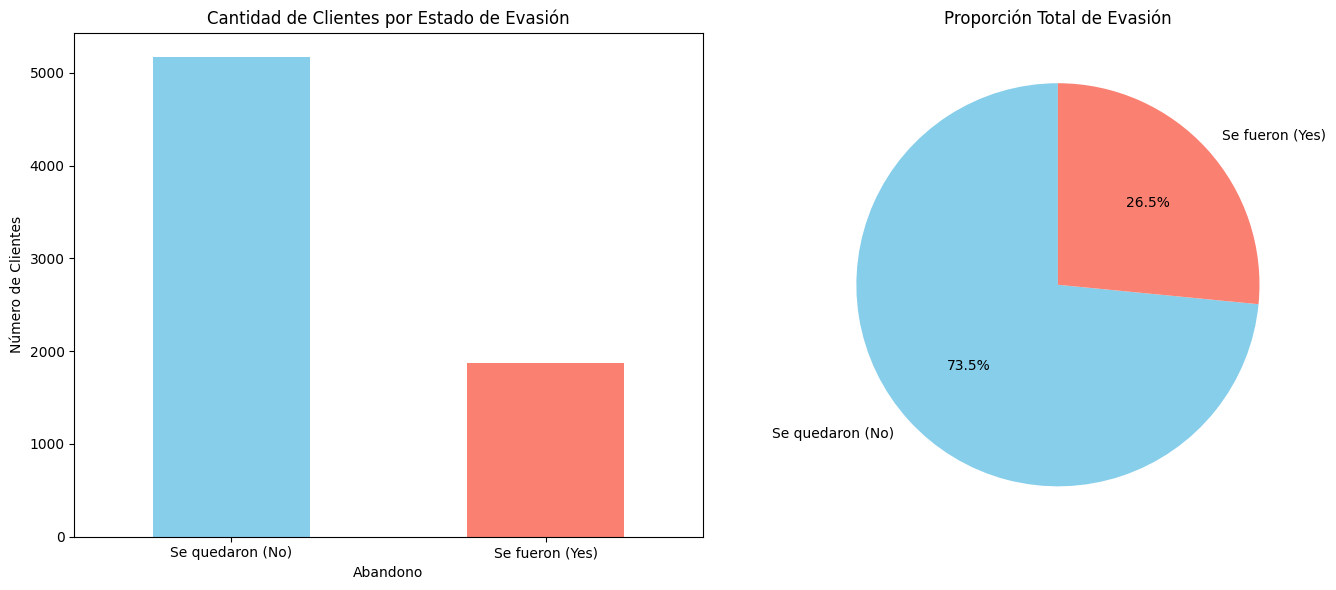

In [22]:
import matplotlib.pyplot as plt

# 1. Contamos cuántos clientes hay en cada categoría
# Mapeamos de nuevo a texto para que el gráfico sea legible para humanos
conteo_evasion = df_telecom['Abandono'].map({1: 'Se fueron (Yes)', 0: 'Se quedaron (No)'}).value_counts()

# 2. Creamos una figura con dos subgráficos (uno al lado del otro)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de Barras
conteo_evasion.plot(kind='bar', color=['skyblue', 'salmon'], ax=ax[0])
ax[0].set_title('Cantidad de Clientes por Estado de Evasión')
ax[0].set_ylabel('Número de Clientes')
ax[0].set_xticklabels(conteo_evasion.index, rotation=0)

# Gráfico de Tarta (Proporción)
conteo_evasion.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'], ax=ax[1], startangle=90)
ax[1].set_title('Proporción Total de Evasión')
ax[1].set_ylabel('') # Quitamos la etiqueta lateral para que se vea limpio

plt.tight_layout()
plt.show()

C:\Users\Danie\AppData\Local\Temp\ipykernel_21156\1721854718.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='Meses_Permanencia', data=df_telecom, palette='Set2', ax=ax[0])
C:\Users\Danie\AppData\Local\Temp\ipykernel_21156\1721854718.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Se Quedan', 'Se Van'])
C:\Users\Danie\AppData\Local\Temp\ipykernel_21156\1721854718.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='Cargo_Mensual', data=df_telecom, palette='Set2', ax=ax[1])
C:\Users\Danie\AppData\Local\Temp\ipykernel_21156\1721854718.py:18: U

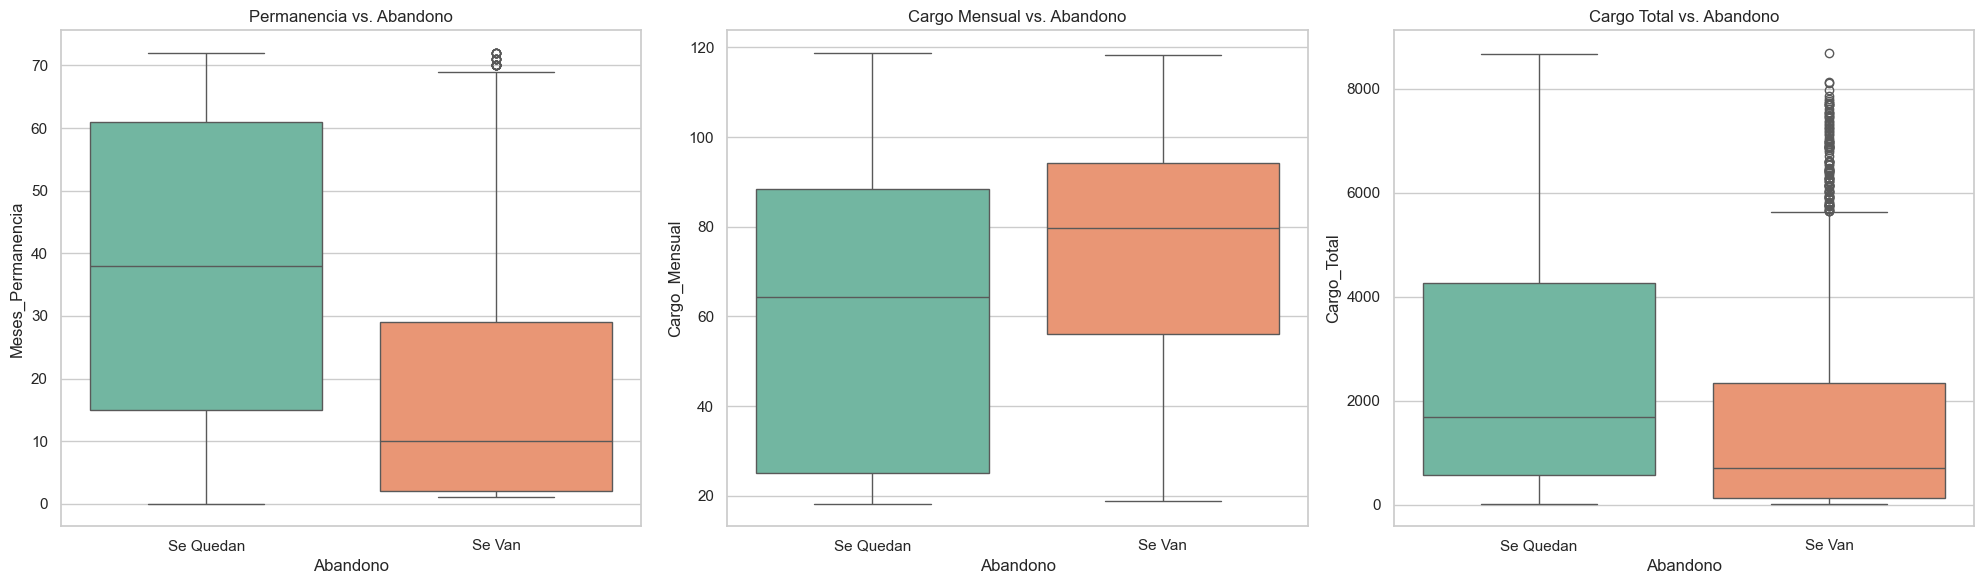

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo para que se vea profesional
sns.set_theme(style="whitegrid")

# Creamos una figura con 3 subgráficos (uno para cada variable)
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1. Comparación por Meses de Permanencia
sns.boxplot(x='Abandono', y='Meses_Permanencia', data=df_telecom, palette='Set2', ax=ax[0])
ax[0].set_title('Permanencia vs. Abandono')
ax[0].set_xticklabels(['Se Quedan', 'Se Van'])

# 2. Comparación por Cargo Mensual
sns.boxplot(x='Abandono', y='Cargo_Mensual', data=df_telecom, palette='Set2', ax=ax[1])
ax[1].set_title('Cargo Mensual vs. Abandono')
ax[1].set_xticklabels(['Se Quedan', 'Se Van'])

# 3. Comparación por Cargo Total
sns.boxplot(x='Abandono', y='Cargo_Total', data=df_telecom, palette='Set2', ax=ax[2])
ax[2].set_title('Cargo Total vs. Abandono')
ax[2].set_xticklabels(['Se Quedan', 'Se Van'])

plt.tight_layout()
plt.show()

#📄Informe final

¡Seaborn versión 0.13.2 listo para la acción!


nforme Final: Análisis de Evasión de Clientes (Churn) - Telecom X
1. Introducción
Objetivo: El presente análisis busca identificar los patrones de comportamiento de los clientes de Telecom X para entender por qué algunos deciden cancelar sus servicios (Churn).
Problema: La pérdida de clientes no solo reduce los ingresos directos, sino que aumenta los costos de adquisición de nuevos usuarios. El objetivo es proporcionar accionables basados en datos para retener a los clientes de alto valor.

2. Limpieza y Tratamiento de Datos
Para asegurar que las conclusiones sean confiables, realizamos el siguiente proceso:

Extracción: Conexión a la API de Telecom X y conversión de formato JSON a DataFrame de Pandas.

Aplanamiento (Flattening): Desglosamos columnas anidadas (customer, internet, account) para acceder a variables específicas como género y tipo de contrato.

Normalización: Renombramos columnas al español y estandarizamos valores de texto.

Depuración: * Convertimos Cargo_Total a formato numérico, gestionando espacios en blanco.

Eliminamos duplicados y tratamos valores nulos.

Transformamos la variable Abandono a formato binario (0 y 1) para facilitar cálculos estadísticos.

3. Análisis Exploratorio de Datos (EDA)
Tras analizar las métricas descriptivas y las visualizaciones, detectamos patrones clave:

📈 Hallazgos Visuales
Tasa de Abandono: La empresa presenta una tasa de evasión de aproximadamente el 26.5%, lo cual es una señal de alerta crítica.

El Factor Tiempo: Los Boxplots de Meses_Permanencia muestran que la mayoría de las fugas ocurren en los primeros 9 meses.

El Factor Económico: Los clientes que abandonan tienden a tener un Cargo_Mensual más elevado en comparación con los que permanecen.

4. Conclusiones e Insights
"Fuga Temprana": Existe una crisis de retención en los clientes nuevos. Si el cliente supera el primer año, la probabilidad de que se quede aumenta drásticamente.

Sensibilidad al Precio: El abandono está correlacionado con facturas altas. Los clientes con cargos mensuales superiores a la media son más propensos a irse a la competencia.

Contratos de Riesgo: Los contratos "Mes a mes" son los principales focos de evasión en comparación con los contratos a largo plazo (1 o 2 años).

5. Recomendaciones Estratégicas
Para reducir el Churn en Telecom X, sugiero las siguientes acciones:

Programa de "Bienvenida Crítica": Implementar descuentos o beneficios especiales durante los primeros 6 meses para asegurar que el cliente supere la etapa de mayor riesgo de fuga.

Migración de Contratos: Crear campañas de marketing para incentivar a los clientes de "Mes a mes" a cambiarse a contratos anuales mediante una pequeña reducción en el cargo mensual.

Alertas de Factura Alta: Monitorear a los clientes cuyos cargos mensuales superen los $70-$80 y ofrecerles paquetes de lealtad o soporte técnico prioritario antes de que decidan cancelar.

Próximos Pasos (Opcional)
Si deseas llevar esto al siguiente nivel en el futuro, podríamos:

Crear un Modelo de Machine Learning que prediga exactamente qué clientes tienen un 90% de probabilidad de irse mañana.

Analizar si el Soporte Técnico (TechSupport) influye en que la gente se quede más tiempo.